# Decision Tree (CART) from Scratch	
### Gini impurity, entropy, recursive split, pruning

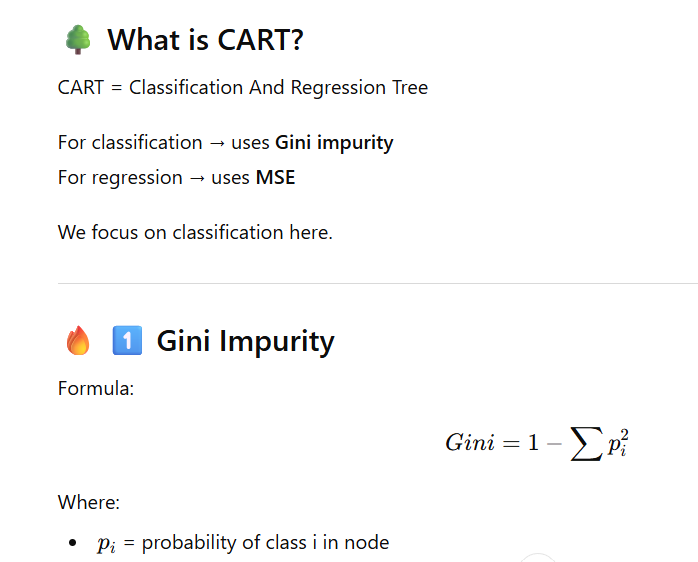

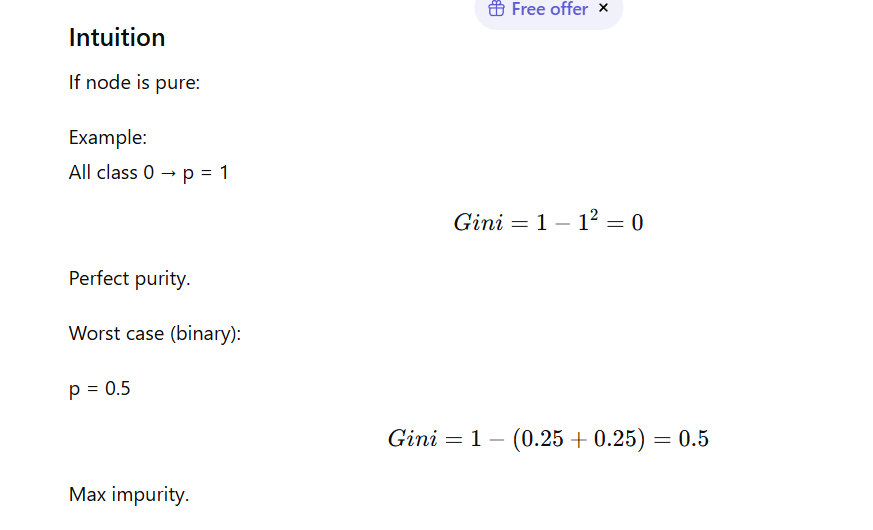

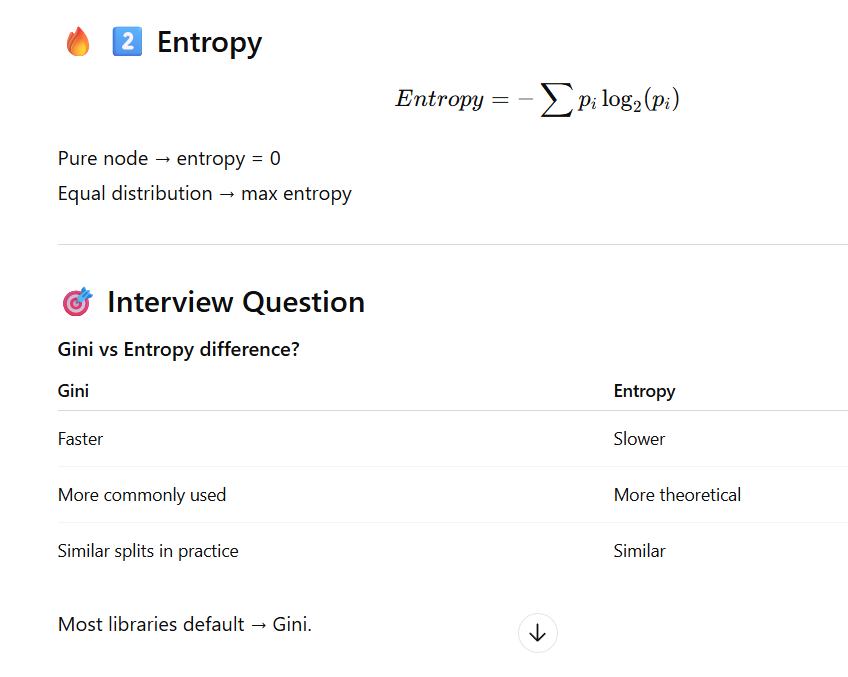

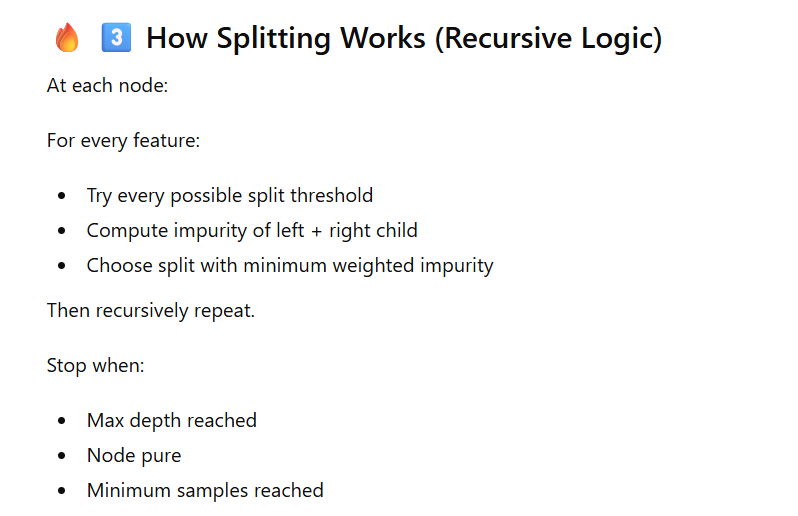

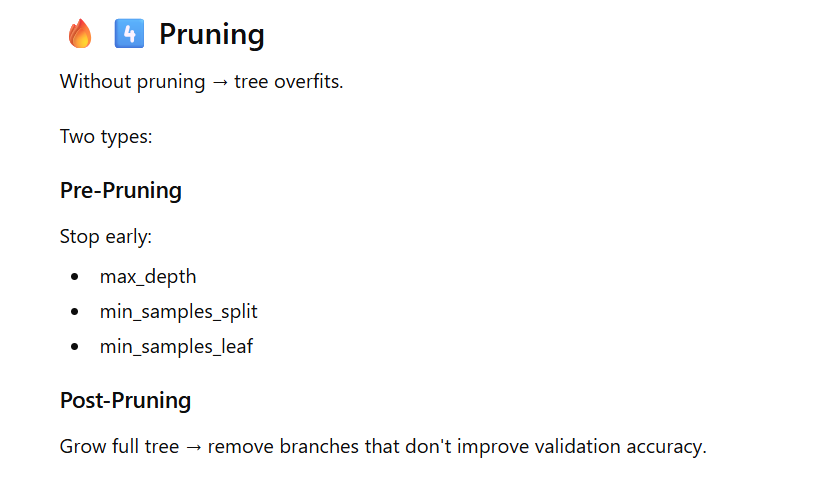

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [8]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def gini(self, y):
        classes = np.unique(y)
        impurity = 1
        for cls in classes:
            p = np.sum(y == cls)/len(y)
            impurity -= p ** 2
        return impurity
    
    def best_split(self, X, y):
        best_feature, best_threshold  = None, None
        best_impurity = float('inf')

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_idx = X[:, feature] <= threshold
                right_idx = X[:, feature] > threshold

                if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
                    continue

                left_impurity = self.gini(y[left_idx])
                right_impurity = self.gini(y[right_idx])

                weighted_impurity = (
                    len(y[left_idx]) / len(y) * left_impurity + len(y[right_idx]) / len(y) * right_impurity 
                )

                if weighted_impurity < best_impurity:
                    best_impurity = weighted_impurity
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold
    
    def build_tree(self, X, y, depth=0):
        if (depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples_split):
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)

        feature, threshold = self.best_split(X, y)
        if feature is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
            
        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        left = self.build_tree(X[left_idx], y[left_idx], depth+1)
        right = self.build_tree(X[right_idx], y[right_idx], depth+1)

        return Node(feature, threshold, left, right)
    
    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict_sample(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_sample(x, node.left)
        return self.predict_sample(x, node.right)
            
    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])



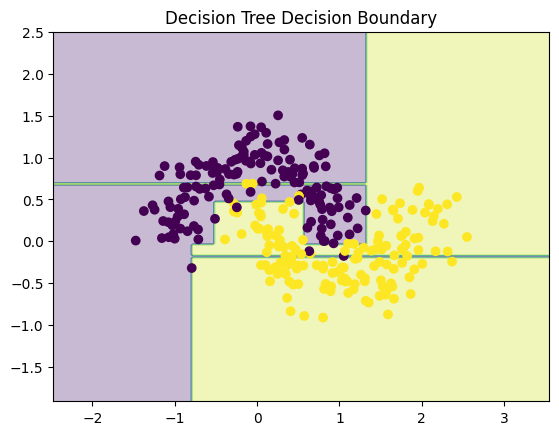

In [9]:
# Generate dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

tree = DecisionTree(max_depth=5)
tree.fit(X, y)

# Plot decision boundary
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = tree.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Tree Decision Boundary")
plt.show()

In [1]:
# Practice 


# Concept 1: Gini Impurity

## Ek Line Mein
> Gini batata hai ki ek group kitna "mixed" hai. **0 = pure, 0.5 = bilkul mixed.**

---

## Real Life Analogy

Do dabbe hain:
```
Dabba A:  🔴 🔴 🔴 🔴   → Pure   → Gini = 0.0
Dabba B:  🔴 🔵 🔴 🔵   → Mixed  → Gini = 0.5
```
Decision Tree chahta hai ki **har group pure ho** — isliye Gini ko minimize karta hai.

---

## Formula

```
Gini = 1 - Σ(pᵢ²)

where pᵢ = probability of class i in the group
```

### Step by Step:
1. Har class ki probability nikalo: `p = count(class) / total`
2. Har p ko square karo: `p²`
3. Sab squares add karo: `Σ(p²)`
4. 1 se ghata do: `1 - Σ(p²)`

---

## Worked Examples

### Example 1 — Pure Group
```
y = [0, 0, 0, 0]
p(0) = 4/4 = 1.0

Gini = 1 - (1.0²)
     = 1 - 1.0
     = 0.0  ✅ Perfect purity
```

### Example 2 — Bilkul Mixed
```
y = [0, 0, 1, 1]
p(0) = 2/4 = 0.5
p(1) = 2/4 = 0.5

Gini = 1 - (0.5² + 0.5²)
     = 1 - (0.25 + 0.25)
     = 1 - 0.5
     = 0.5  ❌ Worst case
```

### Example 3 — Thoda Mixed
```
y = [0, 0, 1, 1, 1]
p(0) = 2/5 = 0.4
p(1) = 3/5 = 0.6

Gini = 1 - (0.4² + 0.6²)
     = 1 - (0.16 + 0.36)
     = 1 - 0.52
     = 0.48
```

### Example 4 — Thoda Impure
```
y = [1, 1, 1, 0]
p(1) = 3/4 = 0.75
p(0) = 1/4 = 0.25

Gini = 1 - (0.75² + 0.25²)
     = 1 - (0.5625 + 0.0625)
     = 1 - 0.625
     = 0.375
```

---

## Gini Values Reference Table

| Group          | Gini  | Matlab              |
|----------------|-------|---------------------|
| [0,0,0,0]      | 0.0   | Pure — ek hi class  |
| [1,1,1,0]      | 0.375 | Thoda mixed         |
| [0,0,1,1,1]    | 0.48  | Zyada mixed         |
| [0,1,0,1]      | 0.5   | 50-50 — worst case  |

---

## Code — From Scratch

```python
import numpy as np

def gini(y):
    classes = np.unique(y)   # Step 1: unique classes nikalo
    impurity = 1
    for cls in classes:
        p = np.sum(y == cls) / len(y)   # Step 2: probability
        impurity -= p**2                 # Step 3: p² ghata do
    return impurity
```

### Code ka Logic Line by Line:
```python
classes = np.unique(y)
# y = [0,0,1,1,1]  →  classes = [0, 1]

p = np.sum(y == cls) / len(y)
# y == 0  →  [True, True, False, False, False]
# np.sum  →  2
# / len(y) → 2/5 = 0.4

impurity -= p**2
# 1 - 0.4² - 0.6² = 1 - 0.16 - 0.36 = 0.48
```

### Test Cases:
```python
print(gini(np.array([0, 0, 0, 0])))      # 0.0
print(gini(np.array([0, 1, 0, 1])))      # 0.5
print(gini(np.array([0, 0, 1, 1, 1])))   # 0.48
print(gini(np.array([1, 1, 1, 0])))      # 0.375
```

---

## Common Mistakes

| Mistake | Sahi Tarika |
|---------|-------------|
| `p = count / total` bhool gaye | Hamesha `np.sum(y == cls) / len(y)` |
| Sirf ek class ka p liya | Loop lagao `np.unique(y)` pe |
| `p` square nahi kiya | `impurity -= p**2` — `**2` zaroor |
| `1 -` lagana bhool gaye | Formula: `impurity = 1`, phir ghata do |

---

## Quick Revision — 3 Sawaal

1. `y = [0,0,0,1]` ka Gini kya hoga? *(Ans: 0.375)*
2. Gini kab 0 hota hai? *(Ans: Jab group pure ho — ek hi class)*
3. `impurity -= p**2` mein `**2` kyun? *(Ans: Formula mein p squared hai)*


In [1]:
import numpy as np

def gini(y):
    # Unique class labels
    classes = np.unique(y)

    # Har class ki probability calculate karo
    impurity = 1
    for cls in classes:
        p = np.sum(y == cls)/len(y)
        # print(p)
        impurity -= p**2
    
    return impurity


# Gini Impurity
y = np.array([0, 0, 1, 1, 1])
gini(y)


np.float64(0.48)

# Concept 2: Weighted Impurity & Best Split

## Ek Line Mein
> Har possible split try karo, jo split weighted Gini minimize kare — wahi best split hai.

---

## Part A: Weighted Impurity

### Kyun Weighted?

Sirf dono sides ka average nahi lete — **bada group zyada important hota hai.**

```
Total = 10 samples

Left  (7 samples): Gini = 0.3
Right (3 samples): Gini = 0.4

Simple avg    = (0.3 + 0.4) / 2       = 0.35   ❌ Wrong
Weighted avg  = (7/10)*0.3 + (3/10)*0.4 = 0.33  ✅ Correct
```

### Formula
```
Weighted Gini = (n_left/n_total) * gini(left) + (n_right/n_total) * gini(right)
```

### Worked Example
```
Total data: 10 samples
Left  (6): [0,0,0,1,0,1]  →  p(0)=4/6, p(1)=2/6  →  Gini = 0.444
Right (4): [1,1,1,0]      →  p(1)=3/4, p(0)=1/4  →  Gini = 0.375

Weighted = (6/10)*0.444 + (4/10)*0.375
         = 0.2664 + 0.150
         = 0.4164
```

---

## Part B: Best Split

### Logic
```
1. Har feature pe loop karo
2. Us feature ki saari unique values = possible thresholds
3. Har threshold pe:
     - Data 2 parts mein baanto (left <= threshold, right > threshold)
     - Weighted Gini calculate karo
     - Agar best se kam hai → update karo
4. Sabse kam Gini wala feature + threshold return karo
```

### Visual
```
Feature 0: [2.5, 1.0, 1.5, 3.0, 2.0]
Feature 1: [1.5, 1.0, 2.0, 3.0, 2.5]
y        : [ 0,   0,   1,   1,   1 ]

Threshold = Feature1, 1.5:
  Left  (<=1.5): y=[0,0]    → Gini=0.0
  Right (>1.5):  y=[1,1,1]  → Gini=0.0
  Weighted = 0.0  ← Best possible!
```

---

## Code

```python
def gini(y):
    classes = np.unique(y)
    impurity = 1
    for cls in classes:
        p = np.sum(y == cls) / len(y)
        impurity -= p**2
    return impurity

def best_split(X, y):
    best_impurity  = float('inf')   # shuruaat mein infinity
    best_feature   = None
    best_threshold = None

    for feature in range(X.shape[1]):          # har feature
        thresholds = np.unique(X[:, feature])  # us feature ki unique values

        for threshold in thresholds:           # har threshold
            left_idx  = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold

            n_total = len(y)
            n_left  = len(y[left_idx])
            n_right = len(y[right_idx])

            if n_left == 0 or n_right == 0:    # empty side → skip
                continue

            weighted_gini = (n_left/n_total)  * gini(y[left_idx]) + \
                            (n_right/n_total) * gini(y[right_idx])

            if weighted_gini < best_impurity:  # better split mila?
                best_impurity  = weighted_gini
                best_feature   = feature
                best_threshold = threshold

    return best_feature, best_threshold        # ← dono loops ke BAAD
```

### Code ka Line-by-Line Logic

| Line | Kya karta hai |
|------|--------------|
| `float('inf')` | Koi bhi impurity isse chhoti hogi — guarantee |
| `X.shape[1]` | Total features ki count |
| `np.unique(X[:, feature])` | Us column ki saari unique values |
| `X[:, feature] <= threshold` | Boolean mask — left side |
| `n_left == 0 or n_right == 0` | Empty split → worthless → skip |
| `if weighted_gini < best_impurity` | Better split mila toh update |
| `return` bahar loops ke | Sab features check hone ke BAAD return |

---

## Common Mistakes

| Mistake | Sahi |
|---------|------|
| `return` loop ke andar | `return` dono loops ke baahir |
| Empty side check nahi kiya | `if n_left == 0 or n_right == 0: continue` |
| `X[:features]` | `X[:, feature]` — comma zaruri |
| Simple average liya | Weighted average lo |

---

## Quick Revision — 3 Sawaal

1. Weighted impurity kyun use karte hain simple average ki jagah?
   *(Ans: Bada group zyada matter karta hai)*

2. `best_impurity = float('inf')` kyun?
   *(Ans: Pehla comparison hamesha True ho — koi bhi value infinity se kam hoti hai)*

3. `return` loop ke andar hone se kya problem hogi?
   *(Ans: Sirf pehla feature check hoga, baaki skip ho jaayenge)*


In [2]:
def best_split(X, y):
    best_impurity = float('inf')
    best_feature = None
    best_threshold = None

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_idx = X[:, feature] <= threshold
            right_idx = X[:, feature] > threshold

            y[left_idx]
            y[right_idx]

            # Weighted Gini Impurity
            n_total = len(y)
            n_left = len(y[left_idx])
            n_right = len(y[right_idx])

            if n_left == 0 or n_right == 0:
                continue

            weighted_gini = (n_left/n_total) * gini(y[left_idx]) + (n_right/n_total) * gini(y[right_idx])

            print(f"Feature: {feature}, Threshold: {threshold}, Weighted Gini: {weighted_gini}")

            if weighted_gini < best_impurity:
                best_impurity = weighted_gini
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold
    
# Example usage
X = np.array([[2.5, 1.5],
              [1.0, 1.0],
              [1.5, 2.0],
              [3.0, 3.0],
              [2.0, 2.5]])
y = np.array([0, 0, 1, 1, 1])
best_feature, best_threshold = best_split(X, y)
print(f"Best Feature: {best_feature}, Best Threshold: {best_threshold}")



Feature: 0, Threshold: 1.0, Weighted Gini: 0.30000000000000004
Feature: 0, Threshold: 1.5, Weighted Gini: 0.4666666666666667
Feature: 0, Threshold: 2.0, Weighted Gini: 0.4666666666666667
Feature: 0, Threshold: 2.5, Weighted Gini: 0.4
Feature: 1, Threshold: 1.0, Weighted Gini: 0.30000000000000004
Feature: 1, Threshold: 1.5, Weighted Gini: 0.0
Feature: 1, Threshold: 2.0, Weighted Gini: 0.26666666666666666
Feature: 1, Threshold: 2.5, Weighted Gini: 0.4
Best Feature: 1, Best Threshold: 1.5


In [3]:
# Building the tree
def build_tree(self, X, y, depth=0):
    # Stopping conditions check karo
    if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples_split:
        leaf_value = np.bincount(y).argmax()
        return Node(value=leaf_value)
    
    # Best split find karo
    feature, threshold = self.best_split(X, y)
    left_idx = X[:, feature] <= threshold
    right_idx = X[:, feature] > threshold
    
    # Recursive calls for left and right subtrees
    left = self.build_tree(X[left_idx], y[left_idx], depth+1)
    right = self.build_tree(X[right_idx], y[right_idx], depth+1)

    # Node return karo
    return Node(feature, threshold, left, right)


def fit(self, X, y):
    self.tree = self.build_tree(X, y)

def predict_sample(self, x, node):
    if node.value is not None:
        return node.value
    
    if x[node.feature] <= node.threshold:
        return self.predict_sample(x, node.left)
    return self.predict_sample(x, node.right)

def predict(self, X):
    return np.array([self.predict_sample(x, self.tree) for x in X])